In [3]:
import pandas as pd
import duckdb
from constants import GRAY_1, GRAY_2, GRAY_3, BLUE_1

df = pd.read_csv("norway_new_car_sales_by_make.csv")
df.head(3)

,Year,Month,Make,Quantity,Pct
0,2007,1,Toyota,2884,22.7
1,2007,1,Volkswagen,2521,19.9
2,2007,1,Peugeot,1029,8.1


In [20]:
df_qty_brand = duckdb.sql("""--sql
SELECT
    make AS Brand,
    SUM(quantity) AS Quantity
FROM df
GROUP BY Brand
ORDER BY Quantity DESC
""").df().set_index("Brand")

df_qty_brand.head()

,Quantity
Brand,
Volkswagen,206669.0
Toyota,168177.0
Volvo,99937.0
Ford,99713.0
BMW,73315.0


# Bar charts


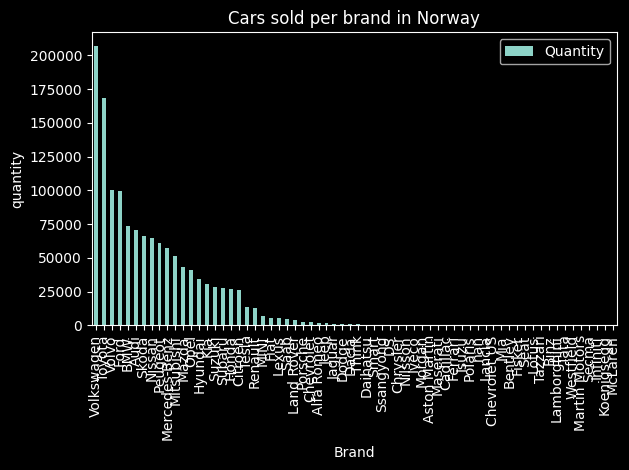

In [24]:
ax = df_qty_brand.plot(kind = "bar", y="Quantity")
ax.set(title= "Cars sold per brand in Norway", ylabel= "quantity")
fig = ax.get_figure()

fig.tight_layout()
fig.savefig("figures/cars_brand_sold.png")